In [1]:
# Import Packages 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
!pip install linearmodels
try:
    from linearmodels.iv import IV2SLS
    HAVE_LINEARMODELS = True
except ImportError:
    HAVE_LINEARMODELS = False
    print("Note: linearmodels not installed. Python IV/2SLS section will not run until installed.")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Load Datasets 
raw_data = pd.read_csv('final_hcris.csv')
data_2009 = pd.read_csv('data/output/data-2009.csv')
data_2010 = pd.read_csv('data/output/data-2010.csv')
data_2011 = pd.read_csv('data/output/data-2011.csv')
data_2012 = pd.read_csv('data/output/data-2012.csv')
data_2013 = pd.read_csv('data/output/data-2013.csv')
data_2014 = pd.read_csv('data/output/data-2014.csv')
data_2015 = pd.read_csv('data/output/data-2015.csv')
data_2016 = pd.read_csv('data/output/data-2016.csv')
data_2017 = pd.read_csv('data/output/data-2017.csv')
data_2018 = pd.read_csv('data/output/data-2018.csv')
data_2019 = pd.read_csv('data/output/data-2019.csv')
data = pd.concat([data_2009, data_2010, data_2011, data_2012, data_2013, data_2014, data_2015, data_2016, data_2017, data_2018, data_2019], ignore_index=True)

In [3]:
data.columns

Index(['provider_number', 'fy_start', 'fy_end', 'date_processed',
       'date_created', 'data_source', 'beds', 'tot_charges', 'net_pat_rev',
       'tot_discounts', 'tot_operating_exp', 'ip_charges', 'icu_charges',
       'ancillary_charges', 'tot_discharges', 'mcare_discharges',
       'mcaid_discharges', 'tot_mcare_payment', 'secondary_mcare_payment',
       'street', 'city', 'state', 'zip', 'county', 'name', 'uncomp_care',
       'cost_to_charge', 'new_cap_ass', 'cash', 'fixed_assets', 'depr_land',
       'depr_bldg', 'depr_lease', 'depr_fixed_equip', 'depr_auto',
       'depr_major_equip', 'depr_minor_equip', 'current_assets',
       'current_liabilities', 'pps_ip_charges', 'pps_op_charges',
       'pps_mcare_cost', 'pps_pgm_cost', 'hvbp_payment', 'hrrp_payment',
       'tot_uncomp_care_charges', 'tot_uncomp_care_partial_pmts', 'bad_debt',
       'depr_HIT', 'year', 'source'],
      dtype='object')

In [4]:
data["name"].unique()

array(['SOUTHEAST ALABAMA MEDICAL CENTER',
       'MARSHALL MEDICAL CENTER - SOUTH', 'MIZELL MEMORIAL HOSPITAL', ...,
       'CUMBERLAND SURGICAL HOSPITAL', 'BSW LAKEWAY',
       'PAM REHAB HOSPITAL CORPUS CHRISTI'], shape=(9355,), dtype=object)

## Question 1

In [5]:
question_1 = (
    raw_data
    .groupby(["fyear", "provider_number"])
    .size()
    .reset_index(name="num_reports")
)
multiple_reports = question_1[question_1["num_reports"] > 1]
multiple_reports.head()

,fyear,provider_number,num_reports
177,2009,40069,2
179,2009,40081,2
197,2009,41316,2
295,2009,50313,2
332,2009,50528,2


In [6]:
hospitals_per_year = (
    multiple_reports
    .groupby("fyear")
    .size()
    .reindex(range(2009, 2020), fill_value=0)
    .reset_index(name="num_hospitals")
)
hospitals_per_year

,fyear,num_hospitals
0,2009,37
1,2010,0
2,2011,45
3,2012,90
4,2013,91
5,2014,102
6,2015,96
7,2016,95
8,2017,91
9,2018,101


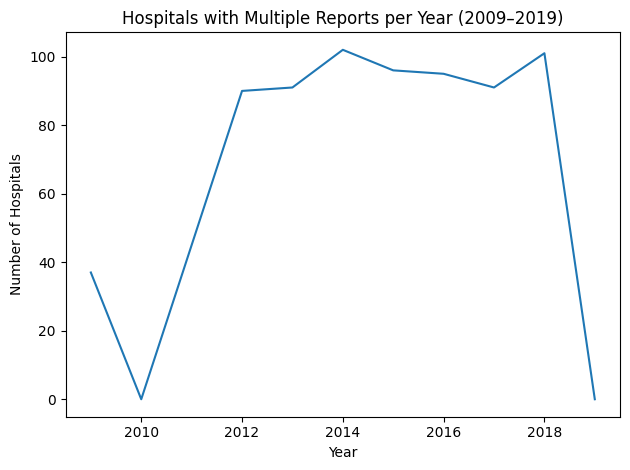

In [7]:
fig, ax = plt.subplots()

ax.plot(
    hospitals_per_year["fyear"],
    hospitals_per_year["num_hospitals"]
)

ax.set(
    xlabel="Year",
    ylabel="Number of Hospitals",
    title="Hospitals with Multiple Reports per Year (2009–2019)"
)

plt.tight_layout()
plt.show()

## Question 2

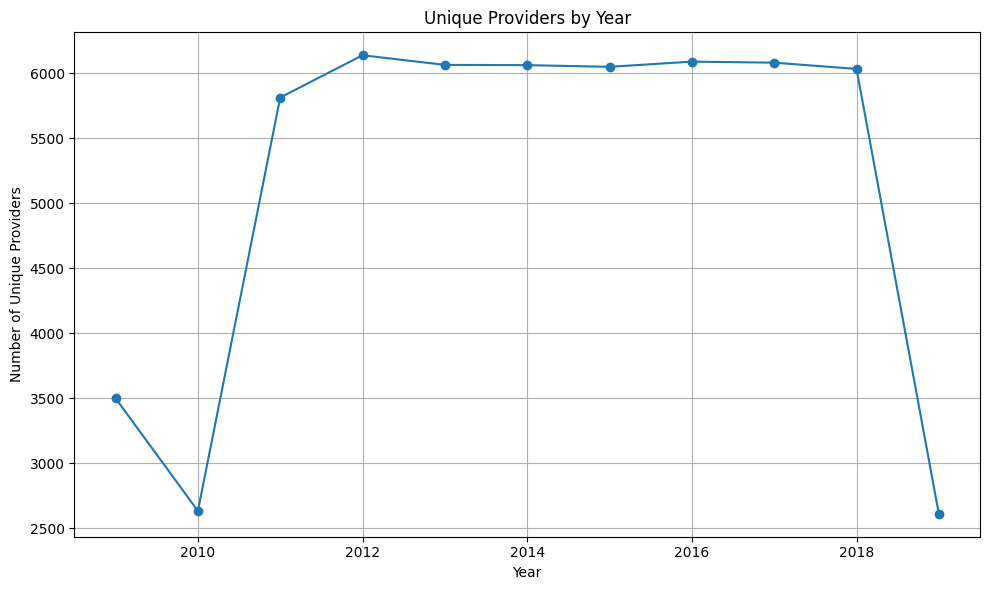

In [8]:
question_2 = data.groupby("year")["provider_number"].nunique()
plt.figure(figsize=(10, 6))
plt.plot(question_2.index, question_2.values, marker="o")

plt.xlabel("Year")
plt.ylabel("Number of Unique Providers")
plt.title("Unique Providers by Year")

plt.grid(True)
plt.tight_layout()
plt.show()

## Question 3

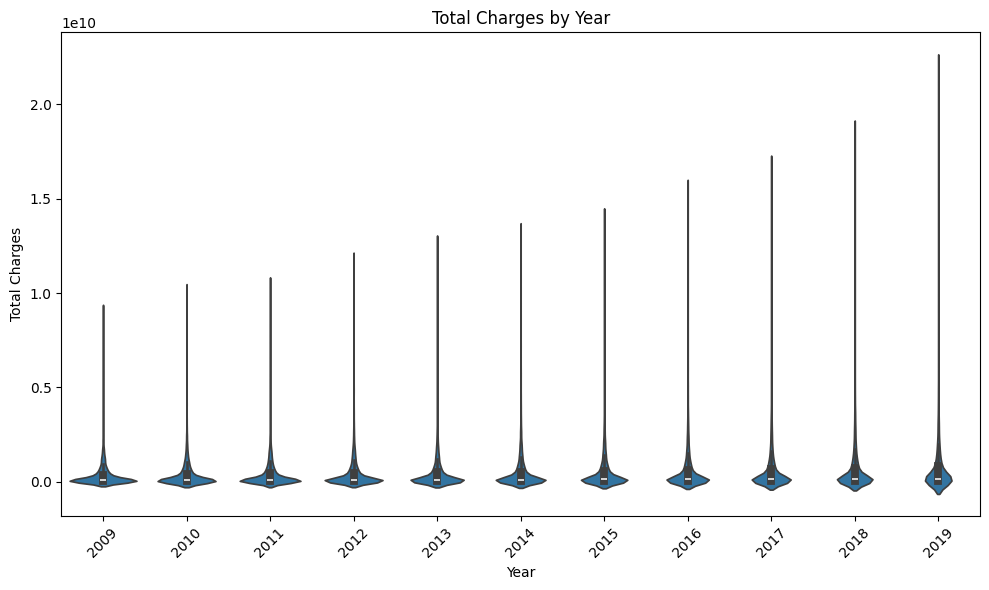

In [22]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=data,
    x="year",
    y="tot_charges"
)

plt.xlabel("Year")
plt.ylabel("Total Charges")
plt.title("Total Charges by Year")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_535217/1901938172.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(winsorize_group3)


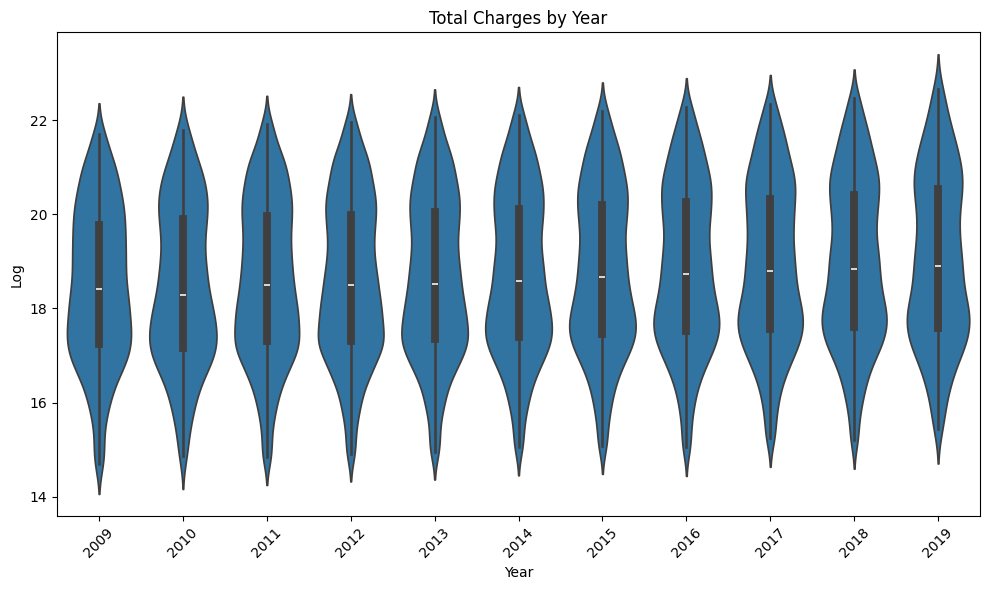

In [23]:
def winsorize_group3(g):
    p99 = g["tot_charges"].quantile(0.99)
    p01 = g["tot_charges"].quantile(0.01)
    g["tot_charges"] = g["tot_charges"].clip(lower=p01, upper=p99)
    return g

question_3 = data.copy() 

winsorized_data3 = (
    question_3.groupby("year", group_keys=False)
    .apply(winsorize_group3)
)

plt.figure(figsize=(10, 6))

winsorized_data3["log_tot_charges"] = np.log(winsorized_data3["tot_charges"])

sns.violinplot(
    data=winsorized_data3,
    x="year",
    y="log_tot_charges"
)

plt.xlabel("Year")
plt.ylabel("Log")
plt.title("Total Charges by Year")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 4

In [24]:
# Price calculation
data["discount_factor"] = 1 - (data["tot_discounts"] / data["tot_charges"])
data["price_num"] = (data["ip_charges"] + data["icu_charges"] + data["ancillary_charges"]) * data["discount_factor"] - data["tot_mcare_payment"]
data["price_denom"] = data["tot_discharges"] - data["mcare_discharges"]
data["price"] = data["price_num"] / data["price_denom"]

In [25]:
data_price = data[(data["price_denom"] > 100) & (data["price_num"] >= 0) & (data["beds"] > 30) & (data["price"] < 100000)].copy()
# def winsorize_group(g):
#     p95 = g["price"].quantile(0.95)
#     p05 = g["price"].quantile(0.05)
#     g["price"] = g["price"].clip(lower=p05, upper=p95)
#     return g

# winsorized_data = (
#     data_price.groupby("year", group_keys=False)
#     .apply(winsorize_group)
# )

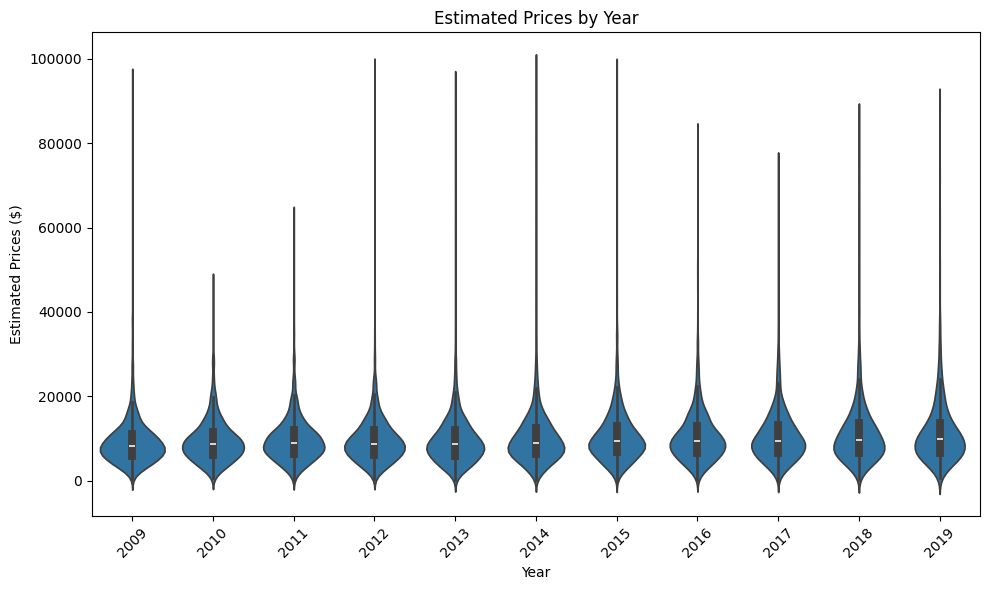

In [26]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=data_price,
    x="year",
    y="price"
)

plt.xlabel("Year")
plt.ylabel("Estimated Prices ($)")
plt.title("Estimated Prices by Year")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 5

In [27]:
# HRRP Penalized Hospitals 
share_year = (
    data
    .assign(
    penalized=np.where(
        (data["hrrp_payment"] > 0) | (data["hvbp_payment"] > 0),
        1,
        0
    )
    )
    .groupby("year", as_index=False)
    .agg(share_penalized=("penalized", "mean"))
)

share_year

,year,share_penalized
0,2009,0.000000
1,2010,0.000000
2,2011,0.000000
3,2012,0.170358
4,2013,0.415265
5,2014,0.443272
6,2015,0.476946
7,2016,0.484814
8,2017,0.482821
9,2018,0.477879


In [28]:
share_year = (
    data
    .dropna(subset=["hrrp_payment"])
    .assign(
        penalized=lambda df: np.where(df["hrrp_payment"] > 0, 1, 0)
    )
    .groupby("year", as_index=False)
    .agg(share_penalized=("penalized", "mean"))
)

share_year

,year,share_penalized
0,2009,0.000000
1,2011,0.000000
2,2012,0.928658
3,2013,0.971042
4,2014,0.977035
5,2015,0.980160
6,2016,0.983265
7,2017,0.984133
8,2018,0.977998
9,2019,1.000000


In [29]:
share_year = (
    data
    .assign(
        penalized=np.where(
            (data["hrrp_payment"].fillna(0) != 0) | 
            (data["hvbp_payment"].fillna(0) != 0),
            1,
            0
        )
    )
    .groupby("year", as_index=False)
    .agg(share_penalized=("penalized", "mean"))
)

share_year

,year,share_penalized
0,2009,0.000000
1,2010,0.000000
2,2011,0.000000
3,2012,0.191368
4,2013,0.467194
5,2014,0.483344
6,2015,0.498595
7,2016,0.502216
8,2017,0.497452
9,2018,0.490307


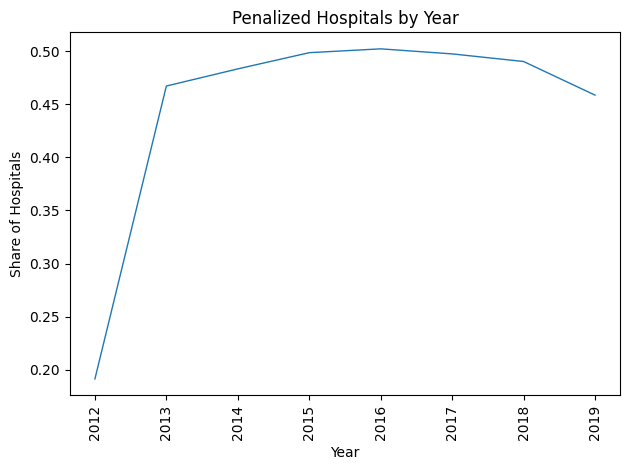

In [30]:
question_5 = share_year[share_year["year"] > 2011]
fig, ax = plt.subplots()
ax.plot(question_5["year"].astype(str), question_5["share_penalized"], linewidth=1)
ax.set_xlabel("Year")
ax.set_ylabel("Share of Hospitals")
ax.set_title("Penalized Hospitals by Year")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## Question 6

In [31]:
# # Prices 
# hcris_price = (
#     data.loc[data["year"].isin([2011, 2014]), ["provider_number", "price", "year"]]
#     .pivot(index="provider_number", columns="year", values="price")
#     .rename(columns=lambda y: f"price_{int(y)}")
#     .reset_index()
# )
# # Penalties 2012
# hcris_hrrp = (
#     data.loc[data["year"].eq(2012), ["provider_number", "hrrp_payment", "hvbp_payment"]]
#     .assign(
#         hrrp_penalty=lambda df: np.where(
#             (df["hrrp_payment"] > 0) & df["hrrp_payment"].notna(),
#             df["hrrp_payment"] / 1000,  # $1000s
#             0.0
#         ),
#         hvbp_penalty=lambda df: np.where(
#             (df["hvbp_payment"] > 0) & df["hvbp_payment"].notna(),
#             df["hvbp_payment"] / 1000,  # $1000s
#             0.0
#         )
#     )
#     .assign(
#         net_penalty=lambda df: df["hrrp_penalty"] + df["hvbp_penalty"]
#     )
#     .loc[:, ["provider_number", "hrrp_penalty", "hvbp_penalty", "net_penalty"]]
# )

# # Medicare discharges (pre-2012 average, in 100s)
# hcris_mcare = (
#     data.loc[data["year"] < 2012, ["provider_number", "mcare_discharges", "beds", "mcaid_discharges"]]
#     .groupby("provider_number", as_index=False)
#     .agg(
#         avg_mcare=("mcare_discharges", lambda x: np.nanmean(x) / 100),
#         avg_beds=("beds", lambda x: np.nanmean(x)),
#         avg_medicaid=("mcaid_discharges", lambda x: np.nanmean(x) / 100)
#     )
# )

# # merge + price change
# hcris_final = (
#     hcris_price
#     .merge(hcris_hrrp, on="provider_number", how="left")
#     .merge(hcris_mcare, on="provider_number", how="left")
# )

# hcris_final = (
#     hcris_final.loc[hcris_final["price_2011"].notna() & hcris_final["price_2014"].notna()]
#     .assign(price_change=lambda df: df["price_2014"] - df["price_2011"])
# )

# hcris_final.head()

In [37]:
# Prices 
hcris_price = (
    data.loc[data["year"].isin([2011, 2014]), ["provider_number", "price", "year"]]
    .pivot(index="provider_number", columns="year", values="price")
    .rename(columns=lambda y: f"price_{int(y)}")
    .reset_index()
)

# Penalties 2012
hcris_hrrp = (
    data.loc[data["year"].eq(2012), ["provider_number", "hrrp_payment", "hvbp_payment"]]
    .assign(
        hrrp_penalty=lambda df: np.where(
            df["hrrp_payment"].notna() & (df["hrrp_payment"] != 0),
            np.abs(df["hrrp_payment"]),  
            0.0
        ),
        hvbp_penalty=lambda df: np.where(
            df["hvbp_payment"].notna() & (df["hvbp_payment"] != 0),
            np.abs(df["hvbp_payment"]),  
            0.0
        )
    )
    .assign(
        net_penalty=lambda df: df["hrrp_penalty"] + df["hvbp_penalty"]
    )
    .loc[:, ["provider_number", "hrrp_penalty", "hvbp_penalty", "net_penalty"]]
)

# Medicare discharges (pre-2012 average, in 100s)
hcris_mcare = (
    data.loc[data["year"] < 2012, ["provider_number", "mcare_discharges", "beds", "mcaid_discharges"]]
    .groupby("provider_number", as_index=False)
    .agg(
        avg_mcare=("mcare_discharges", lambda x: np.nanmean(x)),
        avg_beds=("beds", lambda x: np.nanmean(x)),
        avg_medicaid=("mcaid_discharges", lambda x: np.nanmean(x))
    )
)

# merge + price change
hcris_final = (
    hcris_price
    .merge(hcris_hrrp, on="provider_number", how="left")
    .merge(hcris_mcare, on="provider_number", how="left")
)

hcris_final = (
    hcris_final.loc[hcris_final["price_2011"].notna() & hcris_final["price_2014"].notna()]
    .assign(price_change=lambda df: df["price_2014"] - df["price_2011"])
)

hcris_final.head()

/tmp/ipykernel_535217/4183690686.py:35: RuntimeWarning: Mean of empty slice
  avg_mcare=("mcare_discharges", lambda x: np.nanmean(x)),
/tmp/ipykernel_535217/4183690686.py:36: RuntimeWarning: Mean of empty slice
  avg_beds=("beds", lambda x: np.nanmean(x)),
/tmp/ipykernel_535217/4183690686.py:37: RuntimeWarning: Mean of empty slice
  avg_medicaid=("mcaid_discharges", lambda x: np.nanmean(x))


,provider_number,price_2011,price_2014,hrrp_penalty,hvbp_penalty,net_penalty,avg_mcare,avg_beds,avg_medicaid,price_change
0,10001,4476.453393,5361.016827,0.0,0.0,0.0,7990.0,389.0,3224.5,884.563434
1,10005,1326.689965,1557.153166,0.0,0.0,0.0,2177.0,114.0,1109.0,230.463202
2,10006,4611.551641,4604.281349,0.0,0.0,0.0,5190.0,358.0,1890.0,-7.270292
3,10007,839.569679,422.929891,0.0,0.0,0.0,1118.5,78.0,245.5,-416.639788
6,10011,8309.742656,5159.333559,0.0,0.0,0.0,4182.0,290.5,1468.5,-3150.409098


In [38]:
# OLS 1 
ols_py = smf.ols("price_change ~ net_penalty", data=hcris_final).fit()
print(ols_py.summary())

                            OLS Regression Results                            
Dep. Variable:           price_change   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.1585
Date:                Tue, 31 Mar 2026   Prob (F-statistic):              0.691
Time:                        17:35:34   Log-Likelihood:                -28084.
No. Observations:                2425   AIC:                         5.617e+04
Df Residuals:                    2423   BIC:                         5.618e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     274.4330    550.800      0.498      

In [39]:
# OLS 2
ols_py2 = smf.ols("price_change ~ net_penalty + avg_beds", data=hcris_final).fit()

# OLS 3 
ols_py3 = smf.ols("price_change ~ net_penalty + avg_beds + avg_medicaid", data=hcris_final).fit()

# compact table
out = pd.DataFrame(
    {
        "OLS1": {
            "Net Penalty": ols_py.params["net_penalty"],
            "Std. Error": ols_py.bse["net_penalty"],
            "N": int(ols_py.nobs),
        },
        "OLS2": {
            "Net Penalty": ols_py2.params["net_penalty"],
            "Average Beds": ols_py2.params["avg_beds"],
            "Std. Error": ols_py2.bse["net_penalty"],
            "N": int(ols_py2.nobs),
        },
        "OLS3": {
            "Net Penalty": ols_py3.params["net_penalty"],
            "Average Beds": ols_py3.params["avg_beds"],
            "Average Medicaid": ols_py3.params["avg_medicaid"],
            "Std. Error": ols_py3.bse["net_penalty"],
            "N": int(ols_py3.nobs),
        },
    }
)

out

,OLS1,OLS2,OLS3
Net Penalty,0.004955,0.004860,0.001624
Std. Error,0.012446,0.012451,0.009049
N,2425.000000,2425.000000,2413.000000
Average Beds,NaN,0.084202,0.064810
Average Medicaid,NaN,NaN,0.098264


## Question 7

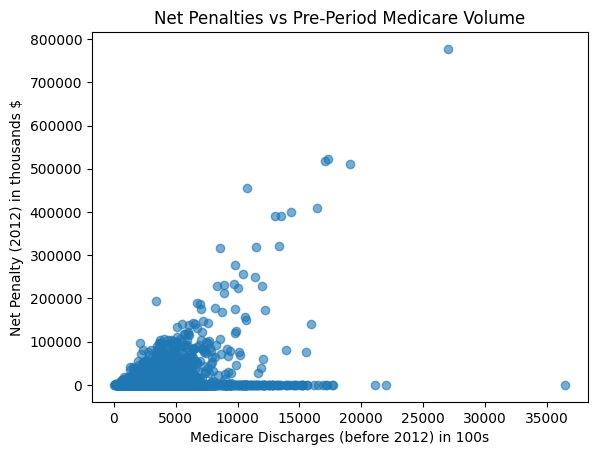

In [40]:
plt.figure()
plt.scatter(hcris_final["avg_mcare"], hcris_final["net_penalty"], alpha=0.6)
plt.xlabel("Medicare Discharges (before 2012) in 100s")
plt.ylabel("Net Penalty (2012) in thousands $")
plt.title("Net Penalties vs Pre-Period Medicare Volume")
plt.show()

## Question 8

In [41]:
first_stage_py = smf.ols("net_penalty ~ avg_mcare", data=hcris_final).fit()
red_form_py   = smf.ols("price_change ~ avg_mcare", data=hcris_final).fit()
first_stage_py2 = smf.ols("net_penalty ~ avg_mcare + avg_beds", data=hcris_final).fit()
red_form_py2   = smf.ols("price_change ~ avg_mcare + avg_beds", data=hcris_final).fit()
first_stage_py3 = smf.ols("net_penalty ~ avg_mcare + avg_beds + avg_medicaid", data=hcris_final).fit()
red_form_py3   = smf.ols("price_change ~ avg_mcare + avg_beds + avg_medicaid", data=hcris_final).fit()
table = pd.DataFrame({
    "First Stage 1": [
        first_stage_py.params["avg_mcare"],
        first_stage_py.bse["avg_mcare"],
        int(first_stage_py.nobs),
        first_stage_py.rsquared
    ],
    "Reduced Form 1": [
        red_form_py.params["avg_mcare"],
        red_form_py.bse["avg_mcare"],
        int(red_form_py.nobs),
        red_form_py.rsquared
    ],
    "First Stage 2": [
        first_stage_py2.params["avg_mcare"],
        first_stage_py2.bse["avg_mcare"],
        int(first_stage_py2.nobs),
        first_stage_py2.rsquared
    ],
    "Reduced Form 2": [
        red_form_py2.params["avg_mcare"],
        red_form_py2.bse["avg_mcare"],
        int(red_form_py2.nobs),
        red_form_py2.rsquared
    ],
    "First Stage 3": [
        first_stage_py3.params["avg_mcare"],
        first_stage_py3.bse["avg_mcare"],
        int(first_stage_py3.nobs),
        first_stage_py3.rsquared
    ],
    "Reduced Form 3": [
        red_form_py3.params["avg_mcare"],
        red_form_py3.bse["avg_mcare"],
        int(red_form_py3.nobs),
        red_form_py3.rsquared
    ],
}, index=["Pre-Penalty Medicare Discharges", "Std. Error", "N", "R-squared"])

table


,First Stage 1,Reduced Form 1,First Stage 2,Reduced Form 2,First Stage 3,Reduced Form 3
Pre-Penalty Medicare Discharges,4.717737,0.399341,4.721659,0.396840,5.303885,0.322182
Std. Error,0.254445,0.166084,0.255124,0.166528,0.296116,0.139571
N,2425.000000,2430.000000,2425.000000,2430.000000,2413.000000,2418.000000
R-squared,0.124253,0.002375,0.124270,0.002394,0.129427,0.002413


In [45]:
first_stage_py = smf.ols("net_penalty ~ avg_mcare", data=hcris_final).fit()
red_form_py   = smf.ols("price_change ~ avg_mcare", data=hcris_final).fit()
first_stage_py2 = smf.ols("net_penalty ~ avg_mcare + avg_beds", data=hcris_final).fit()
red_form_py2   = smf.ols("price_change ~ avg_mcare + avg_beds", data=hcris_final).fit()
first_stage_py3 = smf.ols("net_penalty ~ avg_mcare + avg_beds + avg_medicaid", data=hcris_final).fit()
red_form_py3   = smf.ols("price_change ~ avg_mcare + avg_beds + avg_medicaid", data=hcris_final).fit()
def coef_se(model, var):
    return f"{model.params[var]:.3f}({model.bse[var]:.3f})"
table = pd.DataFrame({
    "First Stage 1": {
        "Pre-Penalty Medicare Discharges": coef_se(first_stage_py, "avg_mcare"),
        "Average Beds": "",
        "Average Medicaid Share": "",
        "N": int(first_stage_py.nobs),
        "R-squared": round(first_stage_py.rsquared, 3)
    },
    "First Stage 2": {
        "Pre-Penalty Medicare Discharges": coef_se(first_stage_py2, "avg_mcare"),
        "Average Beds": coef_se(first_stage_py2, "avg_beds"),
        "Average Medicaid Share": "",
        "N": int(first_stage_py2.nobs),
        "R-squared": round(first_stage_py2.rsquared, 3)
    },
    "First Stage 3": {
        "Pre-Penalty Medicare Discharges": coef_se(first_stage_py3, "avg_mcare"),
        "Average Beds": coef_se(first_stage_py3, "avg_beds"),
        "Average Medicaid Share": coef_se(first_stage_py3, "avg_medicaid"),
        "N": int(first_stage_py3.nobs),
        "R-squared": round(first_stage_py3.rsquared, 3)
    }
})

table

,First Stage 1,First Stage 2,First Stage 3
Pre-Penalty Medicare Discharges,4.718(0.254),4.722(0.255),5.304(0.296)
Average Beds,,-0.076(0.346),-0.055(0.346)
Average Medicaid Share,,,-1.708(0.440)
N,2425,2425,2413
R-squared,0.124,0.124,0.129


In [46]:
def coef_se(model, var):
    return f"{model.params[var]:.3f}({model.bse[var]:.3f})"
table2 = pd.DataFrame({
    "Reduced Stage 1": {
        "Pre-Penalty Medicare Discharges": coef_se(red_form_py, "avg_mcare"),
        "Average Beds": "",
        "Average Medicaid Share": "",
        "N": int(red_form_py.nobs),
        "R-squared": round(red_form_py.rsquared, 3)
    },
    "Reduced Stage 2": {
        "Pre-Penalty Medicare Discharges": coef_se(red_form_py2, "avg_mcare"),
        "Average Beds": coef_se(red_form_py2, "avg_beds"),
        "Average Medicaid Share": "",
        "N": int(red_form_py2.nobs),
        "R-squared": round(red_form_py2.rsquared, 3)
    },
    "Reduced Stage 3": {
        "Pre-Penalty Medicare Discharges": coef_se(red_form_py3, "avg_mcare"),
        "Average Beds": coef_se(red_form_py3, "avg_beds"),
        "Average Medicaid Share": coef_se(red_form_py3, "avg_medicaid"),
        "N": int(red_form_py3.nobs),
        "R-squared": round(red_form_py3.rsquared, 3)
    }
})

table2

,Reduced Stage 1,Reduced Stage 2,Reduced Stage 3
Pre-Penalty Medicare Discharges,0.399(0.166),0.397(0.167),0.322(0.140)
Average Beds,,0.048(0.226),0.046(0.163)
Average Medicaid Share,,,-0.140(0.208)
N,2430,2430,2418
R-squared,0.002,0.002,0.002


## Question 9

In [49]:
# IV/2SLS (Python)
hcris_final = hcris_final.dropna(subset=["net_penalty"])

if not HAVE_LINEARMODELS:
    raise ImportError("Install linearmodels to run IV2SLS: pip install linearmodels")

iv1 = IV2SLS.from_formula(
    "price_change ~ 1 + [net_penalty ~ avg_mcare]",
    data=hcris_final
).fit(cov_type="robust")

iv2 = IV2SLS.from_formula(
    "price_change ~ 1 + avg_beds + [net_penalty ~ avg_mcare]",
    data=hcris_final
).fit(cov_type="robust")

iv3 = IV2SLS.from_formula(
    "price_change ~ 1 + avg_beds + avg_medicaid + [net_penalty ~ avg_mcare]",
    data=hcris_final
).fit(cov_type="robust")

# # compact table
# question_9 = pd.DataFrame(
#     {
#          "IV1": {
#             "Net Penalty ($1000s)": iv1.params["net_penalty"],
#             "Std. Error": iv1.std_errors["net_penalty"],
#             "N": int(iv1.nobs),
#         },
#         "IV2": {
#             "Net Penalty ($1000s)": iv2.params["net_penalty"],
#             "Std. Error": iv2.std_errors["net_penalty"],
#             "N": int(iv2.nobs),
#         },
#         "IV3": {
#             "Net Penalty ($1000s)": iv3.params["net_penalty"],
#             "Std. Error": iv3.std_errors["net_penalty"],
#             "N": int(iv3.nobs),
#         },
#     }
# )
# question_9

/home/segitli/econ470/a0/pyenv/lib/python3.13/site-packages/linearmodels/iv/model.py:560: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(


,IV1,IV2,IV3
Net Penalty ($1000s),0.084487,0.083887,0.060537
Std. Error,0.060754,0.060680,0.066987
N,2425.000000,2425.000000,2413.000000


In [52]:
def coef_se_iv(model, var):
    return f"{model.params[var]:.3f}({model.std_errors[var]:.3f})"
table_iv = pd.DataFrame({
    "IV1": {
        "Net Penalty ($1000s)": coef_se_iv(iv1, "net_penalty"),
        "Average Beds": "",
        "Average Medicaid Share": "",
        "N": int(iv1.nobs),
    },
    "IV2": {
        "Net Penalty ($1000s)": coef_se_iv(iv2, "net_penalty"),
        "Average Beds": coef_se_iv(iv2, "avg_beds"),
        "Average Medicaid Share": "",
        "N": int(iv2.nobs),
    },
    "IV3": {
        "Net Penalty ($1000s)": coef_se_iv(iv3, "net_penalty"),
        "Average Beds": coef_se_iv(iv3, "avg_beds"),
        "Average Medicaid Share": coef_se_iv(iv3, "avg_medicaid"),
        "N": int(iv3.nobs),
    }
})

table_iv

,IV1,IV2,IV3
Net Penalty ($1000s),0.084(0.061),0.084(0.061),0.061(0.067)
Average Beds,,0.055(0.009),0.049(0.006)
Average Medicaid Share,,,-0.036(0.210)
N,2425,2425,2413


## Question 10

The local ATE implies that these treatment effects are on hospitals with high Medicare Discharges (ie a high Medicare population). The effect of net penalties on prices should be higher in this population compared to hospitals with lower Medicare populations because this penalty has a large impact on their net profits.